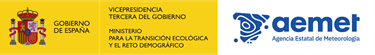

Para abrir el notebook en Colab o Binder pulsa el botón respectivo:

<a target="_blank" href="https://colab.research.google.com/github/pibm-curso/python_para_meteorologia/blob/main/introduccion_ia/ejemplo_overfitting.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
    
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/pibm-curso/python_para_meteorologia/HEAD?urlpath=%2Fdoc%2Ftree%2Fintroduccion_ia%2Fejemplo_overfitting.ipynb)

# Ejemplo de overfitting (sobreajuste) y regularización

In [ ]:
%matplotlib inline

In [ ]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

### Ejemplo: función seno

Para entender como funcionan las técnicas de regularización, vamos a simular la función seno, $y=sin x$ (en python, y=np.sin(x)).  
Añadiremos ruido a la función seno (dibujada entre 60 y 300 grados), y trataremos de ajustar a una función los puntos resultantes.

In [ ]:
rcParams['figure.figsize'] = 12, 10

#Define input array with angles from 60deg to 300deg converted to radians
x = np.array([i*np.pi/180 for i in range(60,300,4)])
np.random.seed(10)  #Setting seed for reproducability

y = np.sin(x) + np.random.normal(0,0.15,len(x))

data = pd.DataFrame(np.column_stack([x,y]),columns=['x','y'])

In [ ]:
plt.plot(data['x'],data['y'],'.')
plt.plot(data['x'],np.sin(data['x']), color='violet')

In [ ]:
xx = np.array([i*np.pi/180 for i in range(60,300,4)])
yy = np.sin(xx) + np.random.normal(0,0.15,len(xx))
data_test = pd.DataFrame(np.column_stack([xx,yy]),columns=['x','y'])

### Regresión lineal

Intentaremos ajustar utilizando quince variables de predicción, desde la primera potencia hasta la quinceava potencia de x, o sea:

$ y = \beta_0 + \beta_1 x^1 + \beta_2 x^2 + ... + \beta_{15} x^{15} = \sum_{j=0}^{15} \beta_j x_i^j $  

In [ ]:
for i in range(2,16):  #power of 1 is already there
    colname = 'x_%d'%i      #new var will be x_power
    data[colname] = data['x']**i
    data_test[colname] = data_test['x']**i
    
print(data.head())

Probamos primero el ajuste utilizando una regresión lineal normal y corriente.

Minimizamos por mínimos cuadrados. Primero probamos un ajuste lineal y luego vamos añadiendo como predictores las potencias de mayor grado hasta 15:  
$ min( \sum_{i=1}^{n} \left( y_i - \sum_{j=0}^{15} \beta_j x_i^j \right)^2) $


In [ ]:
def linear_regression(data, data_test, power, models_to_plot={}):
    predictors = ['x']
    if power >= 2:
        predictors.extend([f'x_{i}' for i in range(2, power + 1)])
    model = make_pipeline(StandardScaler(), LinearRegression())
    model.fit(data[predictors], data['y'])
    y_pred_train = model.predict(data[predictors])
    y_pred_test = model.predict(data_test[predictors])
    
    #Check if a plot is to be made for the entered power
    if power in models_to_plot:
        plt.subplot(models_to_plot[power])
        plt.tight_layout()
        plt.plot(data['x'],y_pred_train)
        plt.plot(data['x'],data['y'],'.')
        plt.title('Gráfica para la potencia: %d'%power)
    
    # convert coefficients back to the original (unscaled) feature space
    scaler = model.named_steps['standardscaler']
    linreg = model.named_steps['linearregression']
    coef = linreg.coef_ / scaler.scale_
    intercept = linreg.intercept_ - np.sum(coef * scaler.mean_)

    rss = np.sum((y_pred_train - data['y']) ** 2)
    rss_test = np.sum((y_pred_test - data_test['y']) ** 2)
    return [rss, rss_test, intercept, *coef]

In [ ]:
#Initialize a dataframe to store the results:
col = ['rss', 'rss_test', 'intercept'] + ['coef_x_%d'%i for i in range(1,16)]
ind = ['model_pow_%d'%i for i in range(1,16)]
coef_matrix_simple = pd.DataFrame(index=ind, columns=col)

#Define the powers for which a plot is required:
models_to_plot = {1:231,3:232,6:233,9:234,12:235,15:236}

#Iterate through all powers and assimilate results
for i in range(1,16):
    coef_matrix_simple.iloc[i-1,0:i+3] = linear_regression(data, data_test, power=i, models_to_plot=models_to_plot)

Analizando los resultados, vemos que hay sobreajuste (overfitting), y que los coeficientes de nuestros parámetros crecen de forma desmesurada:

In [ ]:
#Set the display format to be scientific for ease of analysis
pd.options.display.float_format = '{:,.3g}'.format
coef_matrix_simple

Veamos el error cometido según tomemos solo el conjunto de entrenamiento o también el de validación, según el polinomio utilizado para ajustar:

In [ ]:
fig = plt.figure(figsize=(6,4))
plt.plot(range(1,16), coef_matrix_simple['rss'])
plt.plot(range(1,16), coef_matrix_simple['rss_test'])
plt.title('Residuo según la potencia')
plt.xticks(range(1,16))
plt.ylabel('RSS')
plt.legend(['rss_train', 'rss_test'])

### Ridge regression

En este caso añadimos un término de regularización. Queremos minimizar:  
$ min( \sum_{i=1}^{n} \left( y_i - \sum_{j=0}^{15} \beta_j x_i^j \right)^2 + \alpha \sum_{j=1}^{15} \beta_j^2) $

In [ ]:
def ridge_regression(data, data_test, predictors, alpha, models_to_plot={}):
    
    # fit the model (scaling is needed so the penalty hits all degrees equally)
    model = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    model.fit(data[predictors], data['y'])
    y_pred_train = model.predict(data[predictors])
    y_pred_test = model.predict(data_test[predictors])

    # convert coefficients back to original feature units
    scaler = model.named_steps['standardscaler']
    ridge = model.named_steps['ridge']
    coef = ridge.coef_ / scaler.scale_
    intercept = float(ridge.intercept_ - np.sum(coef * scaler.mean_))

    # plot if requested
    if alpha in models_to_plot:
        plt.subplot(models_to_plot[alpha])
        plt.tight_layout()
        plt.plot(data['x'], y_pred_train, 'g-')
        plt.plot(data['x'], data['y'], '.')
        plt.title('Gráfica para alpha: %.3g'%alpha)

    # return the result in pre-defined format
    rss_train = float(np.sum((y_pred_train - data['y']) ** 2))
    rss_test = float(np.sum((y_pred_test - data_test['y']) ** 2))
    return [rss_train, rss_test, intercept, *coef]

In [ ]:
#Initialize predictors to be set of 15 powers of x
predictors=['x']
predictors.extend(['x_%d'%i for i in range(2,16)])

#Set the different values of alpha to be tested
alpha_ridge = [1e-15, 1e-10, 1e-8, 1e-4, 1e-3,1e-2, 1, 5, 10, 20]

#Initialize the dataframe for storing coefficients.
col = ['rss', 'rss_test', 'intercept'] + ['coef_x_%d'%i for i in range(1,16)]
ind = ['alpha_%.2g'%alpha_ridge[i] for i in range(0,10)]
coef_matrix_ridge = pd.DataFrame(index=ind, columns=col)

models_to_plot = {1e-15:231, 1e-10:232, 1e-4:233, 1e-3:234, 1e-2:235, 5:236}
for i in range(10):
    coef_matrix_ridge.iloc[i,] = ridge_regression(data, data_test, predictors, alpha_ridge[i], models_to_plot)

Hemos evitado el sobreajuste.  
Observar que hay un punto (para un alpha determinado) en el que se obtiene el mejor resultado

In [ ]:
#Set the display format to be scientific for ease of analysis
pd.options.display.float_format = '{:,.3g}'.format
coef_matrix_ridge

### Lasso

Aquí el término de regularización es distinto:  
$ min( \sum_{i=1}^{n} \left( y_i - \sum_{j=0}^{15} \beta_j x_i^j \right)^2 + \alpha \sum_{j=1}^{15} |\beta_j|) $


In [ ]:
def lasso_regression(data, data_test, predictors, alpha, models_to_plot={}):
    
    # fit the model (scaling is needed so the penalty hits all degrees equally)
    model = make_pipeline(StandardScaler(), Lasso(alpha=alpha, max_iter=1e5))
    model.fit(data[predictors], data['y'])
    y_pred_train = model.predict(data[predictors])
    y_pred_test = model.predict(data_test[predictors])

    # convert coefficients back to original feature units
    scaler = model.named_steps['standardscaler']
    lasso = model.named_steps['lasso']
    coef = lasso.coef_ / scaler.scale_
    intercept = float(lasso.intercept_ - np.sum(coef * scaler.mean_))

    # plot if requested
    if alpha in models_to_plot:
        plt.subplot(models_to_plot[alpha])
        plt.tight_layout()
        plt.plot(data['x'], y_pred_train, 'g-')
        plt.plot(data['x'], data['y'], '.')
        plt.title('Gráfica para alpha: %.3g'%alpha)

    # return the result in pre-defined format
    rss_train = float(np.sum((y_pred_train - data['y']) ** 2))
    rss_test = float(np.sum((y_pred_test - data_test['y']) ** 2))
    return [rss_train, rss_test, intercept, *coef]

In [ ]:
#Initialize predictors to all 15 powers of x
predictors=['x']
predictors.extend(['x_%d'%i for i in range(2,16)])

#Define the alpha values to test
alpha_lasso = [1e-15, 1e-10, 1e-8, 1e-5,1e-4, 1e-3,1e-2, 1, 5, 10]

#Initialize the dataframe to store coefficients
col = ['rss', 'rss_test', 'intercept'] + ['coef_x_%d'%i for i in range(1,16)]
ind = ['alpha_%.2g'%alpha_lasso[i] for i in range(0,10)]
coef_matrix_lasso = pd.DataFrame(index=ind, columns=col)

#Define the models to plot
models_to_plot = {1e-10:231, 1e-5:232,1e-4:233, 1e-3:234, 1e-2:235, 1:236}

#Iterate over the 10 alpha values:
for i in range(10):
    coef_matrix_lasso.iloc[i,] = lasso_regression(data, data_test, predictors, alpha_lasso[i], models_to_plot)

Observar los coeficientes que ahora son cero:

In [ ]:
#Set the display format to be scientific for ease of analysis
pd.options.display.float_format = '{:,.3g}'.format
coef_matrix_lasso

In [ ]:
coef_matrix_lasso.apply(lambda x: sum(x.values==0),axis=1)